In [ ]:
import pandas as pd
from io import StringIO
import numpy as np

perch_full = pd.read_csv(r'C:\Machine\perch_csv_data.csv', low_memory=False)
perch_full.head()
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(perch_full, perch_weight, random_state=42)
train_input.shape

(42, 3)

In [31]:
from sklearn.preprocessing import PolynomialFeatures #사이킷런 중 '전처리'(preprocessing) 모듈

poly = PolynomialFeatures(degree = 5, include_bias=False) #다항특성-입력데이터를 다항적인 특성으로 전처리 및 변환
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

print(train_poly.shape, poly.get_feature_names_out())

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

(42, 55) ['length' 'height' 'width' 'length^2' 'length height' 'length width'
 'height^2' 'height width' 'width^2' 'length^3' 'length^2 height'
 'length^2 width' 'length height^2' 'length height width' 'length width^2'
 'height^3' 'height^2 width' 'height width^2' 'width^3' 'length^4'
 'length^3 height' 'length^3 width' 'length^2 height^2'
 'length^2 height width' 'length^2 width^2' 'length height^3'
 'length height^2 width' 'length height width^2' 'length width^3'
 'height^4' 'height^3 width' 'height^2 width^2' 'height width^3' 'width^4'
 'length^5' 'length^4 height' 'length^4 width' 'length^3 height^2'
 'length^3 height width' 'length^3 width^2' 'length^2 height^3'
 'length^2 height^2 width' 'length^2 height width^2' 'length^2 width^3'
 'length height^4' 'length height^3 width' 'length height^2 width^2'
 'length height width^3' 'length width^4' 'height^5' 'height^4 width'
 'height^3 width^2' 'height^2 width^3' 'height width^4' 'width^5']
0.9999999999997232
-144.40564483377855


0.9903815817570367
0.9827976465386928
-144.40564483377855


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

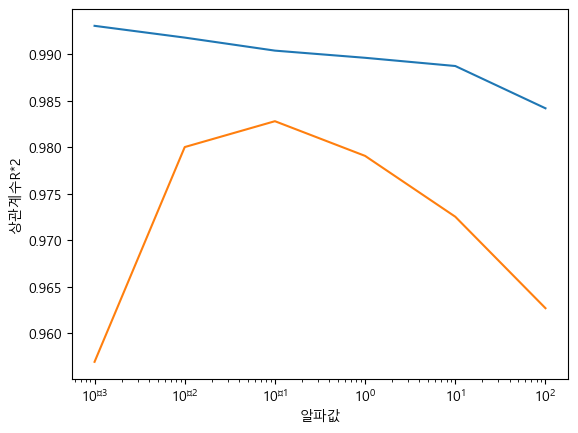

In [49]:
#회귀분석 규제 전 정규화
#사이킷런 모듈의 StandardScaler(정규 스케일링) 패키지
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_poly)
train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

#(1)규제된 회귀분석 : 릿지, 계수 제곱에 규제. 
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.1)
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))
print(lr.score(test_poly, test_target))

train_score = []
test_score = []
alpha_list = [0.001, 0.01, 0.1, 1, 10 ,100]
for a in alpha_list:
    ridge2 = Ridge(alpha=a)
    ridge2.fit(train_scaled, train_target)
    train_score.append(ridge2.score(train_scaled, train_target))
    test_score.append(ridge2.score(test_scaled, test_target))

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
mpl.rcParams['axes.unicode_minus'] = False
plt.rc('axes', unicode_minus = False)
url = r'c:\Windows\Fonts\NanumBarunGothic.ttf'
fm.fontManager.addfont(url)
plt.rc('font', family = 'Malgun Gothic')
plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)
plt.xlabel('알파값')
plt.ylabel('상관계수R*2')
plt.xscale('log')
plt.show()

In [62]:
#(2) 라쏘 규제회귀모델
from sklearn.linear_model import Lasso
lasso2= Lasso(alpha=10)
lasso2.fit(train_scaled, train_target)
print(lasso2.score(train_scaled, train_target))
print(lasso2.score(test_scaled, test_target))

#그래프로 최적 알파 찾기
train_score=[]
test_score=[]
for n in alpha_list:
    lasso=Lasso(alpha=n, max_iter=10000)
    lasso.fit(train_scaled, train_target)
    train_score.append(lasso.score(train_scaled, train_target))
    test_score.append(lasso.score(test_scaled, test_target))
# plt.plot(alpha_list, train_score, c='red')
# plt.plot(alpha_list, test_score, c='blue')
# plt.xlabel('알파')
# plt.ylabel('상관계수')
# plt.xscale('log')
# plt.show()

print(np.sum(lasso2.coef_==0), lasso2.intercept_ )


0.9888067471131866
0.9824470598706695


C:\Users\박중현\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.878e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
C:\Users\박중현\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.297e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


40 400.8333333333333
